In [1]:
# FAKE ACCOUNT DETECTION USING LOGISTIC REGRESSION

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
import pandas as pd

data = {
    "Followers": [
        50,100,150,200,250,300,350,400,450,500,
        600,700,800,900,1000,1200,1500,1800,2000,2500,
        3000,3500,4000,4500,5000,5500,6000,7000,8000,9000,
        10000,12000,15000,18000,20000,25000,30000,35000,40000,50000
    ],

    "Following": [
        500,600,700,800,900,1000,1100,1200,1300,1400,
        1500,1600,1700,1800,1900,2000,2200,2400,2600,2800,
        3000,3200,3500,3800,4000,4200,4500,4800,5000,5500,
        6000,6500,7000,7500,8000,8500,9000,9500,10000,11000
    ],

    "Posts": [
        1,2,3,4,5,6,7,8,9,10,
        12,14,16,18,20,25,30,35,40,45,
        50,55,60,70,80,90,100,120,140,160,
        180,200,220,250,300,350,400,450,500,600
    ],


    "Fake": [
        "Yes","Yes","Yes","Yes","Yes",
        "Yes","Yes","Yes","Yes","Yes",

        "No","No","No","No","No",
        "No","No","No","No","No",

        "No","No","No","No","No",
        "No","No","No","No","No",

        "No","No","No","No","No",
        "No","No","No","No","No"
    ]
}

In [3]:
# CREATE DATAFRAME
records = pd.DataFrame(data)

In [4]:
# SAVE CSV FILE
records.to_csv("fake_accounts_large_dataset.csv", index=False)

# SHOW DATASET
print(records)

print("\nDataset Saved Successfully!")

    Followers  Following  Posts Fake
0          50        500      1  Yes
1         100        600      2  Yes
2         150        700      3  Yes
3         200        800      4  Yes
4         250        900      5  Yes
5         300       1000      6  Yes
6         350       1100      7  Yes
7         400       1200      8  Yes
8         450       1300      9  Yes
9         500       1400     10  Yes
10        600       1500     12   No
11        700       1600     14   No
12        800       1700     16   No
13        900       1800     18   No
14       1000       1900     20   No
15       1200       2000     25   No
16       1500       2200     30   No
17       1800       2400     35   No
18       2000       2600     40   No
19       2500       2800     45   No
20       3000       3000     50   No
21       3500       3200     55   No
22       4000       3500     60   No
23       4500       3800     70   No
24       5000       4000     80   No
25       5500       4200     90   No
2

In [5]:
# SHOW DATASET
print("Dataset:\n")
print(records)



Dataset:

    Followers  Following  Posts Fake
0          50        500      1  Yes
1         100        600      2  Yes
2         150        700      3  Yes
3         200        800      4  Yes
4         250        900      5  Yes
5         300       1000      6  Yes
6         350       1100      7  Yes
7         400       1200      8  Yes
8         450       1300      9  Yes
9         500       1400     10  Yes
10        600       1500     12   No
11        700       1600     14   No
12        800       1700     16   No
13        900       1800     18   No
14       1000       1900     20   No
15       1200       2000     25   No
16       1500       2200     30   No
17       1800       2400     35   No
18       2000       2600     40   No
19       2500       2800     45   No
20       3000       3000     50   No
21       3500       3200     55   No
22       4000       3500     60   No
23       4500       3800     70   No
24       5000       4000     80   No
25       5500       4200    

In [6]:
# SHOW FIRST 5 ROWS
print("\nFirst 5 Rows:\n")
print(records.head())



First 5 Rows:

   Followers  Following  Posts Fake
0         50        500      1  Yes
1        100        600      2  Yes
2        150        700      3  Yes
3        200        800      4  Yes
4        250        900      5  Yes


In [7]:
# DATASET INFORMATION
print("\nDataset Info:\n")
print(records.info())



Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Followers  40 non-null     int64
 1   Following  40 non-null     int64
 2   Posts      40 non-null     int64
 3   Fake       40 non-null     str  
dtypes: int64(3), str(1)
memory usage: 1.4 KB
None


In [8]:

# CHECK MISSING VALUES
print("\nMissing Values:\n")
print(records.isnull().sum())


Missing Values:

Followers    0
Following    0
Posts        0
Fake         0
dtype: int64


In [9]:
# CONVERT TARGET VARIABLE INTO BINARY
records["Fake"] = records["Fake"].map({
    "Yes": 1,
    "No": 0
})

In [10]:

# SHOW UPDATED DATASET
print("\nUpdated Dataset:\n")
print(records)



Updated Dataset:

    Followers  Following  Posts  Fake
0          50        500      1     1
1         100        600      2     1
2         150        700      3     1
3         200        800      4     1
4         250        900      5     1
5         300       1000      6     1
6         350       1100      7     1
7         400       1200      8     1
8         450       1300      9     1
9         500       1400     10     1
10        600       1500     12     0
11        700       1600     14     0
12        800       1700     16     0
13        900       1800     18     0
14       1000       1900     20     0
15       1200       2000     25     0
16       1500       2200     30     0
17       1800       2400     35     0
18       2000       2600     40     0
19       2500       2800     45     0
20       3000       3000     50     0
21       3500       3200     55     0
22       4000       3500     60     0
23       4500       3800     70     0
24       5000       4000     80

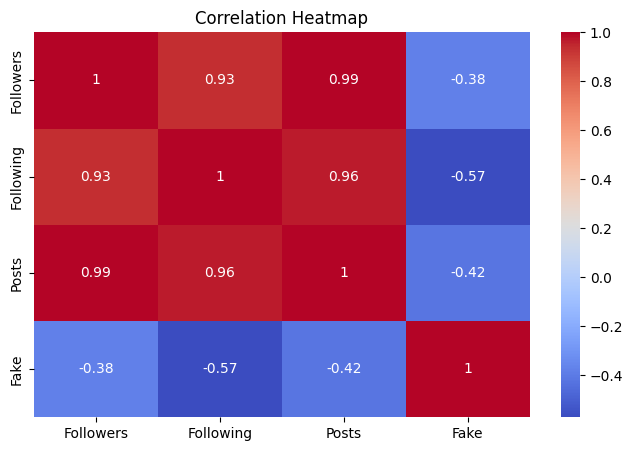

In [11]:
# CORRELATION HEATMAP
plt.figure(figsize=(8,5))

sns.heatmap(records.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()


In [12]:

# FEATURES AND TARGET
X = records[[
    "Followers",
    "Following",
    "Posts"
]]

y = records["Fake"]

In [13]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# SHOW TRAINING DATA
print("\nX Train:\n")
print(X_train)

print("\nX Test:\n")
print(X_test)


X Train:

    Followers  Following  Posts
39      50000      11000    600
6         350       1100      7
25       5500       4200     90
9         500       1400     10
13        900       1800     18
31      12000       6500    200
34      20000       8000    300
8         450       1300      9
17       1800       2400     35
24       5000       4000     80
0          50        500      1
33      18000       7500    250
5         300       1000      6
11        700       1600     14
1         100        600      2
29       9000       5500    160
21       3500       3200     55
2         150        700      3
30      10000       6000    180
36      30000       9000    400
3         200        800      4
35      25000       8500    350
23       4500       3800     70
32      15000       7000    220
10        600       1500     12
22       4000       3500     60
18       2000       2600     40
20       3000       3000     50
7         400       1200      8
14       1000       1900     

In [15]:
# CREATE MODEL
model = LogisticRegression()

In [16]:
# TRAIN MODEL
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
# PREDICTIONS
y_pred = model.predict(X_test)


In [18]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)




Confusion Matrix:

[[7 0]
 [0 1]]


In [19]:
# CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [20]:
# ACCURACY SCORE
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)


Accuracy Score: 1.0


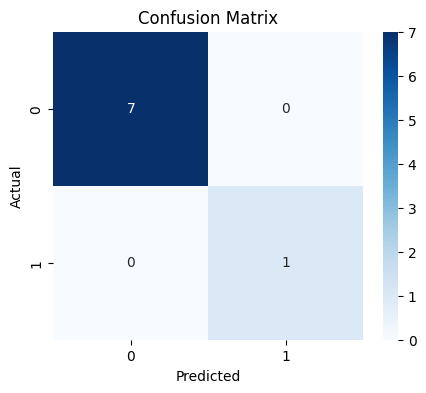

In [21]:
# CONFUSION MATRIX HEATMAP
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [ ]:
# USER INPUT

while True:

    try:

        followers = int(input("Enter Followers: "))
        following = int(input("Enter Following: "))
        posts = int(input("Enter Posts: "))

        new_account = pd.DataFrame({
            "Followers": [followers],
            "Following": [following],
            "Posts": [posts]
        })

        prediction = model.predict(new_account)

        if prediction[0] == 1:
            print("\nFake Account Detected")

        else:
            print("\nReal Account")

        again = input("\nCheck Another Account? (yes/no): ")

        if again.lower() != "yes":
            break

    except ValueError:
        print("\nPlease Enter Valid Numbers Only!")


Fake Account Detected


In [ ]:

# SAVE MODEL
import joblib

joblib.dump(model, "fake_account_detection_model.pkl")

print("\nModel Saved Successfully!")